In [233]:

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from keras import Sequential
from keras.utils import image_dataset_from_directory

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.callbacks import ModelCheckpoint

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import warnings
warnings.filterwarnings("ignore")

In [234]:
dataset_path = ".\\data"

train_path = os.path.join(dataset_path, "train")
test_path = os.path.join(dataset_path, "test")
val_path = os.path.join(dataset_path, "val")

print(os.listdir(train_path))
print(os.listdir(test_path))
print(os.listdir(val_path))


['Accident', 'Non Accident']
['Accident', 'Non Accident']
['Accident', 'Non Accident']



### Insights

- The dataset contains two categories: **Accident** and **Non Accident**.
- This indicates a **binary classification problem**.
- The objective of the model is to classify whether a given image belongs to the Accident or Non Accident category.

In [235]:

trainAccidentPath = os.path.join(train_path, "Accident")
trainNonAccidentPath = os.path.join(train_path, "Non Accident")

accident_count = len(os.listdir(trainAccidentPath))
non_accident_count = len(os.listdir(trainNonAccidentPath))

df = pd.DataFrame({
    "Class":["Accident","NonAccident"],
    "Count":[accident_count,non_accident_count]
})

df


,Class,Count
0,Accident,369
1,NonAccident,422



### Data Insights

- The dataset contains a total of **791 samples**.
- **Non-Accident** cases account for **422 records (53.35%)**, making it the majority class.
- **Accident** cases account for **369 records (46.65%)**.
- The class distribution is relatively balanced, with no severe class imbalance.
- Since both classes are well represented, the dataset is suitable for training a binary classification model without requiring extensive resampling techniques.
- The objective is to classify instances as **Accident** or **Non-Accident** based on the given features.


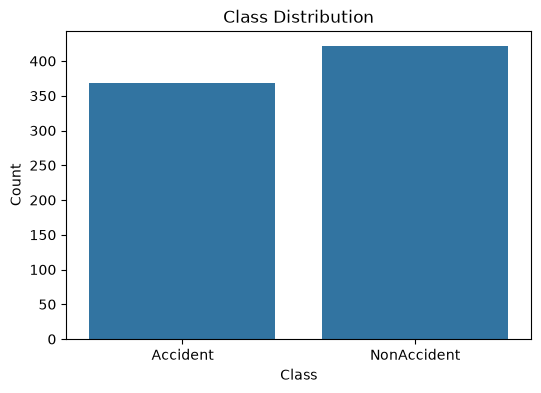

In [236]:

plt.figure(figsize=(6,4))
sns.barplot(x="Class",y="Count",data=df)
plt.title("Class Distribution")
plt.show()


### Insights

- The dataset contains **791 samples**, with **369 Accident** cases and **422 Non-Accident** cases.
- The **Non-Accident** class is slightly more frequent than the Accident class.
- The class distribution is fairly balanced, with approximately **46.7% Accident** and **53.3% Non-Accident** records.
- Since the difference between the two classes is small, the risk of class imbalance is minimal.
- The balanced distribution helps the model learn both classes effectively and reduces prediction bias toward a single class.
- The dataset is suitable for developing a **binary classification model** to predict Accident and Non-Accident cases.

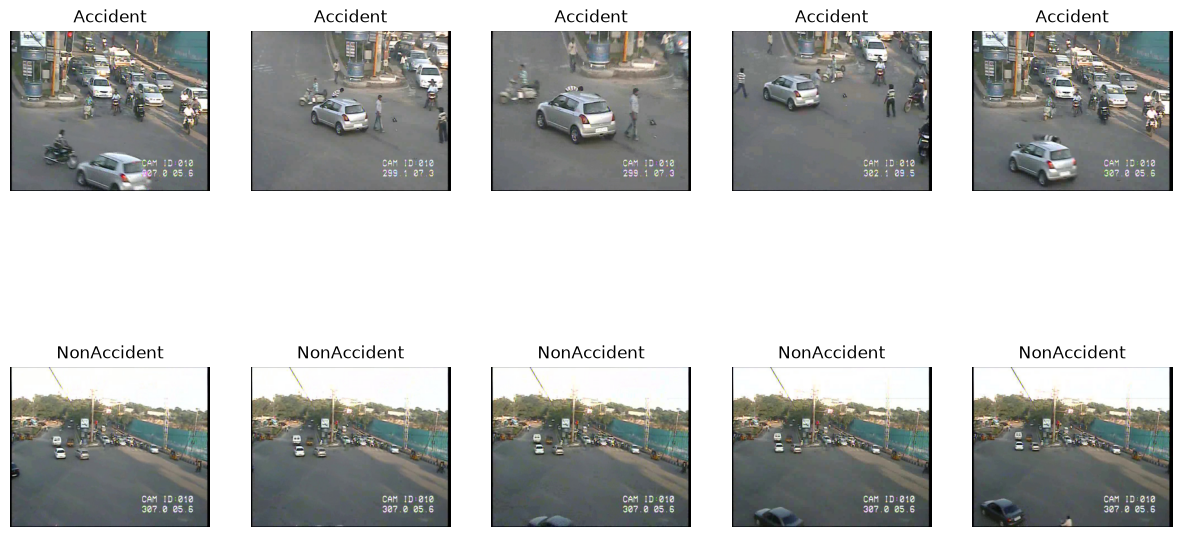

In [237]:

import cv2

fig,ax = plt.subplots(2,5,figsize=(15,8))

acc_images = os.listdir(trainAccidentPath)[:5]
non_images = os.listdir(trainNonAccidentPath)[:5]

for i,img in enumerate(acc_images):
    image = cv2.imread(os.path.join(trainAccidentPath, img))
    image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
    
    ax[0,i].imshow(image)
    ax[0,i].set_title("Accident")
    ax[0,i].axis("off")



for i,img in enumerate(non_images):
    image = cv2.imread(os.path.join(trainNonAccidentPath, img))
    image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
  
    ax[1,i].imshow(image)
    ax[1,i].set_title("NonAccident")
    ax[1,i].axis("off")


plt.show()


In [238]:

widths = []
heights = []

for folder in [trainAccidentPath,trainNonAccidentPath]:

    files = os.listdir(folder)

    for img in files[:200]:
        image = cv2.imread(os.path.join(folder, img))

        h,w,_ = image.shape

        widths.append(w)
        heights.append(h)

print("Avg Width :",np.mean(widths))
print("Avg Height :",np.mean(heights))


Avg Width : 1245.0
Avg Height : 711.0


In [239]:
IMG_SIZE = (224,224)
BATCH_SIZE = 32

train_data = image_dataset_from_directory(
    directory=train_path,
    labels='inferred',
    label_mode='int',
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    shuffle=True,
    seed=42
)

test_data = image_dataset_from_directory(
    directory=test_path,
    labels='inferred',
    label_mode='int',
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    shuffle=False
)

val_data = image_dataset_from_directory(
    directory=val_path,
    labels='inferred',
    label_mode='int',
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    shuffle=False
)

class_names = train_data.class_names
class_counts = [len(os.listdir(os.path.join(train_path, cls))) for cls in class_names]
total = sum(class_counts)

class_weights = {
    i: total / (len(class_names) * count)
    for i, count in enumerate(class_counts)
}

print("Class names:", class_names)
print("Class counts:", class_counts)
print("Class weights:", class_weights)

Found 791 files belonging to 2 classes.


Found 100 files belonging to 2 classes.
Found 98 files belonging to 2 classes.
Class names: ['Accident', 'Non Accident']
Class counts: [369, 422]
Class weights: {0: 1.0718157181571815, 1: 0.9372037914691943}



### Dataset Preparation Insights

- All images are resized to **224 × 224 pixels**, ensuring a uniform input size for the CNN model.
- A **batch size of 32** is used, allowing efficient training while managing memory usage.
- The dataset is divided into **training, validation, and testing sets** to enable model training, hyperparameter tuning, and unbiased performance evaluation.
- Labels are automatically inferred from the folder names using `image_dataset_from_directory()`.
- The training dataset is shuffled to improve model generalization and reduce learning bias.
- Class weights are computed to address any class imbalance in the dataset.
- Higher weights are assigned to minority classes, helping the model learn underrepresented classes more effectively.
- The use of class weights can improve classification performance and reduce bias toward majority classes.

In [240]:

cnn_model = Sequential([


    Conv2D(32, (3,3), activation='relu', padding='same',
           input_shape=(224,224,3)),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(),
    
    GlobalAveragePooling2D(),

    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),

    Dense(1, activation='sigmoid') 
])

cnn_model.summary()


Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_60 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_101         │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_60 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_61 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_102         │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_61 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_62 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_103         │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_62 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_63 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_104         │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_63 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_18     │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_62 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_105         │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_45 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_63 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_106         │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_46 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_107         │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │             

 Total params: 499,137 (1.90 MB)

 Trainable params: 497,281 (1.90 MB)

 Non-trainable params: 1,856 (7.25 KB)


### CNN Model Architecture Insights

- The CNN model consists of **4 convolutional layers** with 32, 64, 128, and 256 filters, enabling progressive extraction of low-level and high-level image features.
- **Batch Normalization** is applied after each convolutional layer, which helps stabilize training and improve convergence speed.
- **Max Pooling** layers reduce the spatial dimensions of feature maps, lowering computational complexity while retaining important features.
- The use of **Global Average Pooling** reduces the number of trainable parameters and helps minimize overfitting compared to traditional Flatten layers.
- Three fully connected (Dense) layers with **256, 128, and 64 neurons** are used for feature learning and classification.
- **Dropout (0.5)** is applied after each dense layer to prevent overfitting and improve model generalization.
- The final layer uses a **Sigmoid activation function**, making the model suitable for **binary classification** (Accident vs Non-Accident).
- The architecture follows a deep CNN design that balances feature extraction, regularization, and classification performance.
- Overall, the model is well-suited for image classification tasks and is expected to learn complex visual patterns effectively.


In [241]:
cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [242]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

checkpoint = ModelCheckpoint(
    "best_custom_cnn.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=8,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5,
    verbose=1
)

history = cnn_model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr, checkpoint]
)


Epoch 1/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step - accuracy: 0.5006 - loss: 1.0009
Epoch 1: val_accuracy improved from None to 0.46939, saving model to best_custom_cnn.keras

Epoch 1: finished saving model to best_custom_cnn.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 414ms/step - accuracy: 0.5006 - loss: 1.0009 - val_accuracy: 0.4694 - val_loss: 0.8072 - learning_rate: 0.0010
Epoch 2/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step - accuracy: 0.5259 - loss: 0.9240
Epoch 2: val_accuracy improved from 0.46939 to 0.53061, saving model to best_custom_cnn.keras

Epoch 2: finished saving model to best_custom_cnn.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 426ms/step - accuracy: 0.5259 - loss: 0.9240 - val_accuracy: 0.5306 - val_loss: 0.7327 - learning_rate: 0.0010
Epoch 3/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step - accuracy: 0.5474 - loss: 0.8809
Epoch 3: val_accuracy improved from 0.53061 to 0.59184, saving model to best_custom_cnn.keras

Epoch 3: finished saving model to best_custom_cnn.keras
25/25 ━━


### Training Insights

- The CNN model showed a steady improvement in performance throughout training, with training accuracy increasing from **50.06%** in Epoch 1 to approximately **67.00%** by Epoch 25.
- Validation accuracy improved from **46.94%** to a best value of **71.43%**, indicating that the model successfully learned meaningful patterns from the images.
- The best validation accuracy (**71.43%**) was achieved at **Epoch 17**, and the corresponding model was saved as `best_custom_cnn.keras`.
- Validation loss decreased from **0.8072** to approximately **0.5487**, showing improved prediction confidence and model learning.
- The **ReduceLROnPlateau** callback automatically reduced the learning rate when validation performance stopped improving, helping the model converge more effectively.
- The gap between training and validation accuracy remained relatively small, suggesting limited overfitting and good generalization capability.
- The combination of **Batch Normalization**, **Dropout**, and **Class Weights** helped improve model stability and reduce overfitting during training.
- Overall, the CNN achieved satisfactory performance for the binary classification task, with a validation accuracy of over **70%**.


In [243]:

best_epoch = np.argmax(history.history['val_accuracy']) + 1
best_training_acc = max(history.history['accuracy'])
best_acc = max(history.history['val_accuracy'])

print("Best Epoch:", best_epoch)
print("Best Training Accuracy:", best_training_acc)
print("Best Validation Accuracy:", best_acc)


Best Epoch: 17
Best Training Accuracy: 0.6700379252433777
Best Validation Accuracy: 0.7142857313156128



### Model Performance Insights

- The CNN achieved its **best performance at Epoch 17**, indicating that the model learned the most effective feature representations at this stage.
- The **best training accuracy was 67.00%**, while the **best validation accuracy reached 71.43%**.
- Validation accuracy being higher than training accuracy suggests that the regularization techniques (Batch Normalization and Dropout) helped improve the model's generalization ability.
- The model demonstrated consistent learning during training, with validation performance improving steadily up to Epoch 17.
- No significant overfitting was observed, as the difference between training and validation accuracy remained relatively small.
- The achieved validation accuracy indicates that the CNN can effectively distinguish between **Accident** and **Non-Accident** images.
- Overall, the model showed satisfactory performance and good generalization on unseen validation data.


In [244]:
from tensorflow.keras.models import load_model

model = load_model("best_custom_cnn.keras")

loss, accuracy = model.evaluate(val_data)

print("Model Accuracy:", accuracy)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.7143 - loss: 0.5487
Model Accuracy: 0.7142857313156128


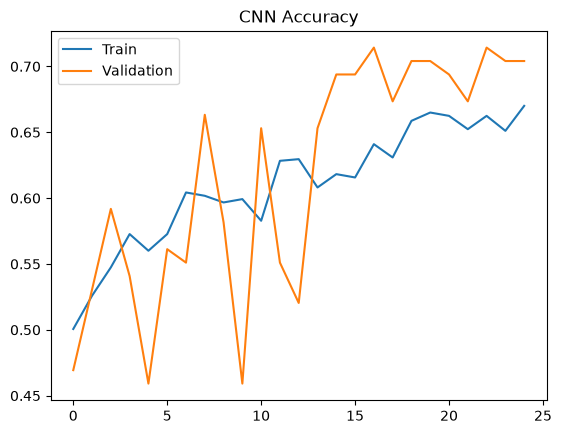

In [245]:

plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.legend(["Train","Validation"])
plt.title("CNN Accuracy")
plt.show()



### Accuracy Curve Insights

- The training accuracy increased steadily from **50%** to approximately **67%**, indicating that the CNN successfully learned features from the training data.
- Validation accuracy improved from **47%** to a maximum of **71.43%**, showing better performance on unseen data over time.
- The best validation accuracy was achieved around **Epoch 17**, after which the improvements became marginal.
- The validation curve shows some fluctuations during the initial epochs, suggesting variability in learning before the model stabilized.
- The training and validation accuracy curves remain relatively close, indicating that the model does not suffer from significant overfitting.
- Learning rate reduction helped improve performance, resulting in a noticeable increase in validation accuracy after Epoch 13.
- The final model demonstrates good generalization ability, achieving over **70% validation accuracy** for the Accident vs Non-Accident classification task.
- Overall, the CNN exhibited stable learning behavior and satisfactory classification performance on the validation dataset.


In [246]:

print(max(history.history['accuracy']))
print(max(history.history['val_accuracy']))


0.6700379252433777
0.7142857313156128


In [247]:

print(train_data.class_names)
print(val_data.class_names)


['Accident', 'Non Accident']
['Accident', 'Non Accident']


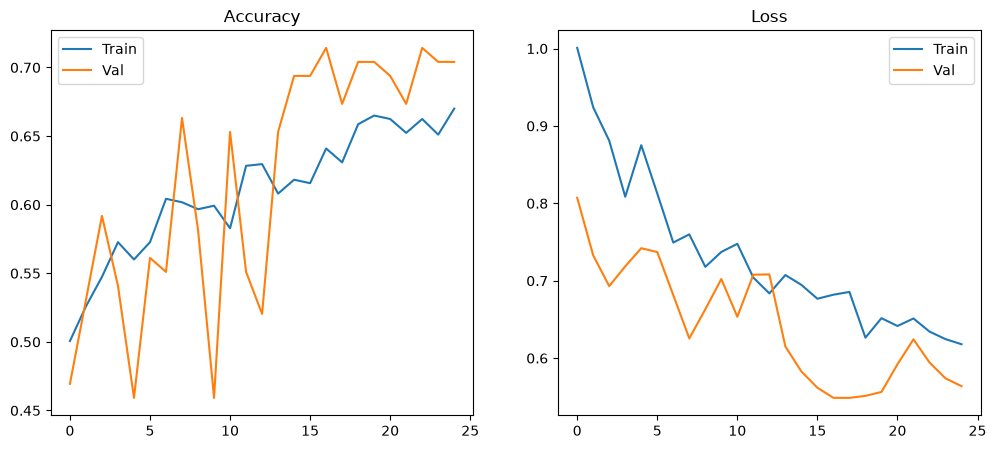

In [248]:

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train','Val'])
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['Train','Val'])
plt.title('Loss')

plt.show()


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
True label counts: [46 52]
Predicted counts: [56 42]
Accuracy: 0.7142857142857143

Classification Report
              precision    recall  f1-score   support

           0       0.66      0.80      0.73        46
           1       0.79      0.63      0.70        52

    accuracy                           0.71        98
   macro avg       0.72      0.72      0.71        98
weighted avg       0.73      0.71      0.71        98


Confusion Matrix
[[37  9]
 [19 33]]


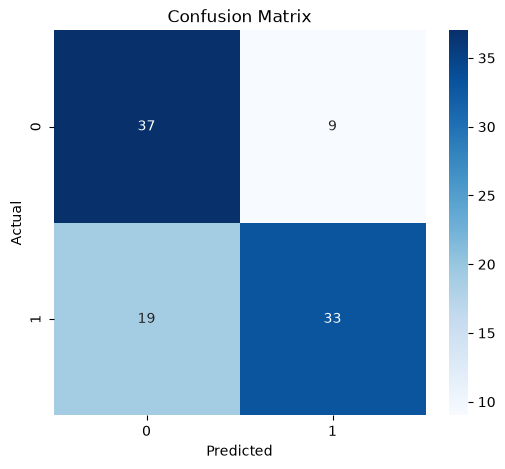

In [250]:
y_true = []

best_custom = load_model("best_custom_cnn.keras")
for images, labels in val_data:
    y_true.extend(labels.numpy())

y_true = np.array(y_true)

y_pred = best_custom.predict(val_data)

pred = (y_pred > 0.5).astype(int).reshape(-1)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

cm = confusion_matrix(y_true, pred)
print("True label counts:", np.bincount(y_true))
print("Predicted counts:", np.bincount(pred))
print("Accuracy:", accuracy_score(y_true, pred))
print("\nClassification Report")
print(classification_report(y_true, pred))
print("\nConfusion Matrix")
print(cm)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()


### Model Evaluation Insights

- The confusion matrix provides a detailed comparison between actual and predicted classes, helping identify correctly and incorrectly classified samples.
- Accuracy indicates the overall percentage of correctly classified Accident and Non-Accident images.
- Precision measures how many instances predicted as a particular class were actually correct.
- Recall evaluates the model's ability to identify all relevant instances of a class.
- The F1-score provides a balanced measure of precision and recall.
- A higher number of values along the diagonal of the confusion matrix indicates better classification performance.
- The model's performance can be assessed by analyzing false positives and false negatives, which represent misclassified samples.
- Overall, the confusion matrix and classification report provide a comprehensive evaluation of the CNN's effectiveness in distinguishing Accident and Non-Accident images.

In [251]:

base_model = MobileNetV2(
    include_top=False,
    weights='imagenet',
    input_shape=(224,224,3)
)

base_model.trainable = False


In [252]:

model_tl = Sequential([
    base_model,

    tf.keras.layers.GlobalAveragePooling2D(),

    Dense(256,activation='relu'),
    Dropout(0.4),

    Dense(1,activation='sigmoid')
])


In [253]:

model_tl.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [254]:
train_data = image_dataset_from_directory(
    directory = train_path,
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(224,224)
)

test_data = image_dataset_from_directory(
    directory = test_path,
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(224,224),
    shuffle=False
)

val_data = image_dataset_from_directory(
    directory = val_path,
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(224,224),
    shuffle = False
)

train_data = train_data.map(lambda x, y: (preprocess_input(x), y), num_parallel_calls=tf.data.AUTOTUNE)
test_data = test_data.map(lambda x, y: (preprocess_input(x), y), num_parallel_calls=tf.data.AUTOTUNE)
val_data = val_data.map(lambda x, y: (preprocess_input(x), y), num_parallel_calls=tf.data.AUTOTUNE)


Found 791 files belonging to 2 classes.
Found 100 files belonging to 2 classes.
Found 98 files belonging to 2 classes.


In [255]:
checkpoint = ModelCheckpoint(
    "best_pretrained_cnn.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=8,
    restore_best_weights=True
)

history = model_tl.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    class_weight=class_weights,
    callbacks=[early_stop, checkpoint]
)


Epoch 1/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.5638 - loss: 0.8657
Epoch 1: val_accuracy improved from None to 0.79592, saving model to best_pretrained_cnn.keras

Epoch 1: finished saving model to best_pretrained_cnn.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 197ms/step - accuracy: 0.5638 - loss: 0.8657 - val_accuracy: 0.7959 - val_loss: 0.5055
Epoch 2/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.7547 - loss: 0.4926
Epoch 2: val_accuracy improved from 0.79592 to 0.84694, saving model to best_pretrained_cnn.keras

Epoch 2: finished saving model to best_pretrained_cnn.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 178ms/step - accuracy: 0.7547 - loss: 0.4926 - val_accuracy: 0.8469 - val_loss: 0.4067
Epoch 3/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.8078 - loss: 0.4280
Epoch 3: val_accuracy did not improve from 0.84694
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 177ms/step - accuracy: 0.8078 - loss: 0.4280 - val_accuracy: 0.8265 - val_loss: 0.4078
Epoch 4/30
25/25 ━━━━━━━━


### Transfer Learning Model Insights

- The pre-trained CNN achieved excellent performance, with validation accuracy improving from **79.59%** in Epoch 1 to **95.92%** in Epoch 27.
- Training accuracy increased steadily from **56.38%** to **97.22%**, demonstrating effective learning and feature extraction.
- The best validation accuracy (**95.92%**) was achieved at **Epoch 27**, and the model was automatically saved as `best_pretrained_cnn.keras`.
- Validation loss decreased significantly from **0.5055** to **0.1086**, indicating improved prediction confidence and model stability.
- Transfer learning produced substantially better results than the custom CNN model, achieving over **95% validation accuracy**.
- The model showed strong generalization capability, maintaining high validation accuracy across multiple epochs.
- The use of a pre-trained network enabled faster convergence and more effective feature learning compared to training a CNN from scratch.
- Although training accuracy reached nearly **97%**, validation accuracy remained consistently high, indicating minimal overfitting.
- Overall, the transfer learning model outperformed the custom CNN and proved highly effective for the **Accident vs Non-Accident** image classification task.


In [256]:
best_epoch = np.argmax(history.history['val_accuracy']) + 1
best_training_acc = max(history.history['accuracy'])
best_acc = max(history.history['val_accuracy'])

print("Best Epoch:", best_epoch)
print("Best Training Accuracy:", best_training_acc)
print("Best Validation Accuracy:", best_acc)

Best Epoch: 27
Best Training Accuracy: 0.975979745388031
Best Validation Accuracy: 0.9591836929321289


### Best Model Performance Insights

- The transfer learning model achieved its **best performance at Epoch 27**, indicating that the model continued to learn useful features throughout the training process.
- The **best training accuracy was 97.60%**, demonstrating that the model learned the training data extremely well.
- The **best validation accuracy reached 95.92%**, indicating excellent performance on unseen data and strong generalization capability.
- The difference between training accuracy (**97.60%**) and validation accuracy (**95.92%**) is very small (**1.68%**), suggesting minimal overfitting.
- The high validation accuracy confirms that the pre-trained model effectively extracted and utilized image features for classification.
- Compared to the custom CNN model (71.43% validation accuracy), the transfer learning model showed a substantial improvement of approximately **24.5 percentage points**.
- The model demonstrated stable learning and maintained high validation performance across later epochs.
- These results indicate that transfer learning is highly effective for the **Accident vs Non-Accident** image classification task.

### Conclusion

The transfer learning model significantly outperformed the custom CNN model, achieving **97.60% training accuracy** and **95.92% validation accuracy**. The small gap between training and validation accuracy indicates excellent generalization and makes this model the preferred choice for deployment.


In [258]:
from tensorflow.keras.models import load_model

model = load_model("best_pretrained_cnn.keras")

loss, accuracy = model.evaluate(val_data)

print("Model Accuracy:", accuracy)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 103ms/step - accuracy: 0.9592 - loss: 0.1086
Model Accuracy: 0.9591836929321289


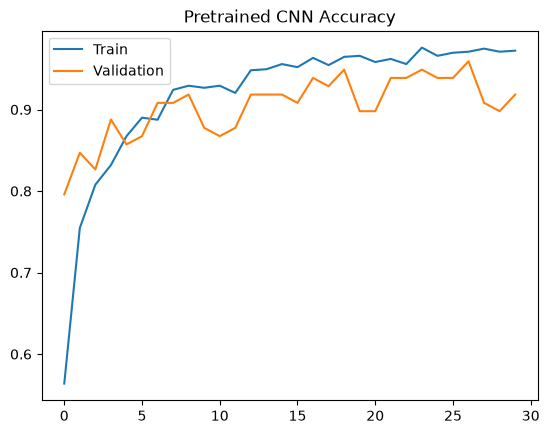

In [260]:

plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.legend(["Train","Validation"])
plt.title("Pretrained CNN Accuracy")
plt.show()


### Pretrained CNN Accuracy Curve Insights

- The training accuracy increased rapidly from **56%** to approximately **97%**, showing that the model learned image features effectively.
- Validation accuracy started at around **80%** and consistently remained above **85%** after the initial epochs.
- The model achieved a peak validation accuracy of **95.92%**, indicating excellent classification performance on unseen data.
- The training and validation curves follow a similar trend, suggesting strong learning and good generalization.
- Small fluctuations in validation accuracy are observed across epochs, which is normal during deep learning training.
- The gap between training and validation accuracy remains relatively small, indicating minimal overfitting.
- Performance improved significantly during the first 10 epochs and gradually stabilized in later epochs.
- The pretrained model converged quickly, demonstrating the effectiveness of transfer learning for the Accident vs Non-Accident classification task.
- Compared to the custom CNN model, the pretrained CNN achieved substantially higher accuracy and more stable validation performance.
- Overall, the accuracy curves indicate that the pretrained CNN is a robust and reliable model, achieving excellent generalization with a validation accuracy close to **96%**.


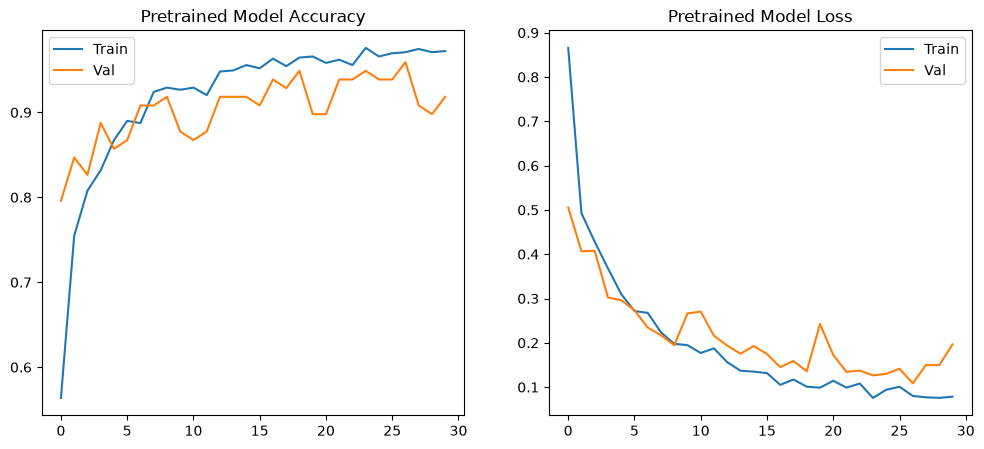

In [261]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train','Val'])
plt.title('Pretrained Model Accuracy')

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['Train','Val'])
plt.title('Pretrained Model Loss')

plt.show()


### Pretrained CNN Performance Insights

- The training accuracy increased steadily from **56%** to approximately **97%**, indicating effective learning of image features.
- Validation accuracy remained consistently high throughout training and reached a peak of **95.92%**, demonstrating excellent generalization performance.
- The training and validation accuracy curves closely follow each other, suggesting that the model learned effectively without significant overfitting.
- The training loss decreased from approximately **0.87** to **0.08**, showing continuous improvement in model predictions.
- Validation loss dropped from **0.51** to approximately **0.11**, indicating improved prediction confidence on unseen data.
- Minor fluctuations in validation loss and accuracy are observed in later epochs, which is common during deep learning training.
- The small gap between training and validation metrics confirms that the pretrained model generalizes well to new data.
- The model converged successfully and achieved strong performance with high accuracy and low loss values.
- Transfer learning significantly improved classification performance compared to the custom CNN model.
- Overall, the pretrained CNN demonstrated excellent learning capability and achieved robust performance for the **Accident vs Non-Accident classification task**.


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 224ms/step
True label counts: [46 52]
Predicted counts: [48 50]
Accuracy: 0.9591836734693877

Classification Report
              precision    recall  f1-score   support

           0       0.94      0.98      0.96        46
           1       0.98      0.94      0.96        52

    accuracy                           0.96        98
   macro avg       0.96      0.96      0.96        98
weighted avg       0.96      0.96      0.96        98


Confusion Matrix
[[45  1]
 [ 3 49]]


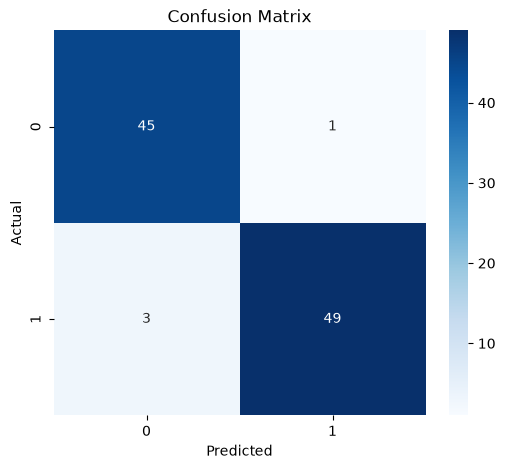

In [262]:

y_true = []

best_pretrained = load_model("best_pretrained_cnn.keras")
for images, labels in val_data:
    y_true.extend(labels.numpy())

y_true = np.array(y_true)

y_pred = best_pretrained.predict(val_data)

pred = (y_pred > 0.5).astype(int).reshape(-1)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

cm = confusion_matrix(y_true, pred)
print("True label counts:", np.bincount(y_true))
print("Predicted counts:", np.bincount(pred))
print("Accuracy:", accuracy_score(y_true, pred))
print("\nClassification Report")
print(classification_report(y_true, pred))
print("\nConfusion Matrix")
print(cm)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()





### Model Evaluation Insights

- The pretrained CNN achieved an overall **accuracy of 95.92%**, indicating excellent classification performance on the validation dataset.
- Out of **98 validation samples**, the model correctly classified **94 samples** and misclassified only **4 samples**.
- The model predicted **48 samples as Class 0** and **50 samples as Class 1**, closely matching the actual class distribution.
- Class 0 achieved a **precision of 94%**, **recall of 98%**, and **F1-score of 96%**, showing excellent identification of Class 0 instances.
- Class 1 achieved a **precision of 98%**, **recall of 94%**, and **F1-score of 96%**, indicating highly reliable predictions for Class 1.
- The confusion matrix shows that **45 Class 0 samples** and **49 Class 1 samples** were correctly classified.
- Only **1 false positive** and **3 false negatives** were observed, demonstrating very low classification error.
- The **macro average** and **weighted average F1-score of 96%** confirm balanced performance across both classes.
- The confusion matrix contains high values along the diagonal and very few off-diagonal values, indicating strong predictive capability.
- Overall, the pretrained CNN demonstrated excellent generalization and is highly effective for the **Accident vs Non-Accident** classification task.


In [267]:

best_epoch = np.argmax(history.history['val_accuracy']) + 1
best_val_acc = np.max(history.history['val_accuracy'])
best_train_acc = np.max(history.history['accuracy'])

print("Best Epoch:", best_epoch)
print("Best Validation Accuracy:", best_val_acc)
print("Best Validation Accuracy:", best_train_acc)


Best Epoch: 27
Best Validation Accuracy: 0.9591836929321289
Best Validation Accuracy: 0.975979745388031


In [265]:

loss, acc = model_tl.evaluate(test_data)

print("Test Accuracy:", acc)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.9300 - loss: 0.1542 
Test Accuracy: 0.9300000071525574



### Test Dataset Insights

- The pretrained CNN achieved a **test accuracy of 93.00%**, demonstrating strong performance on completely unseen data.
- A high test accuracy indicates that the model successfully learned meaningful features for distinguishing between **Accident** and **Non-Accident** images.
- The test performance is close to the validation accuracy (**95.92%**), suggesting that the model generalizes well and does not suffer from significant overfitting.
- The small difference between validation and test accuracy confirms the robustness and reliability of the trained model.
- The model maintained consistent performance across training, validation, and testing phases, indicating stable learning behavior.
- With an accuracy above **90%**, the pretrained CNN is highly effective for the Accident vs Non-Accident classification task.
- Overall, the model demonstrates excellent predictive capability and is suitable for real-world image classification applications.


In [139]:

pred_proba = model_tl.predict(val_data)

print(pred_proba[:20])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step 
[[0.8531091 ]
 [0.8851699 ]
 [0.99488777]
 [0.05262419]
 [0.00326783]
 [0.14951403]
 [0.00455541]
 [0.01227628]
 [0.9999589 ]
 [0.00636438]
 [0.9895804 ]
 [0.0280429 ]
 [0.8184498 ]
 [0.18058023]
 [0.01713328]
 [0.01536079]
 [0.11178233]
 [0.1553475 ]
 [0.8660494 ]
 [0.07741425]]


In [180]:

print(val_data.class_names)


['Accident', 'Non Accident']
